# Fraud Detection — Extended Modelling Notebook

This notebook extends the original fraud detection analysis with:
- Robust preprocessing (pipeline-based, no data leakage)
- Many more models (linear, tree, boosting, distance-based, probabilistic, ensembles)
- Class imbalance handling (class_weight, SMOTE, undersampling)
- Hyperparameter tuning (RandomizedSearchCV)
- Stratified cross-validation comparison
- Per-model threshold optimization (F1 / F2)
- Full model comparison table + ROC/PR curve overlays
- Feature importance & SHAP explainability
- Best model export

Run cells top to bottom. `fraud_oracle.csv` must be in the same folder as this notebook.


## 0. Setup & Installs
Run once. Safe to re-run.

In [1]:
# Install extra libraries if missing (safe to re-run)
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg, imp in [
    ("xgboost", "xgboost"),
    ("lightgbm", "lightgbm"),
    ("catboost", "catboost"),
    ("imbalanced-learn", "imblearn"),
    ("shap", "shap"),
]:
    ensure(pkg, imp)

print("Setup complete.")


Setup complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score, fbeta_score, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Data

In [3]:
df = pd.read_csv('fraud_oracle.csv')
print(df.shape)
df.head()


(15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Cleaning
Same cleaning as the original notebook (drop the bad `DayOfWeekClaimed == '0'` rows).

In [4]:
print("Duplicates:", df.duplicated().sum())
print("Nulls:\n", df.isnull().sum().sum())

df = df[df['DayOfWeekClaimed'] != '0'].reset_index(drop=True)
print("Shape after cleaning:", df.shape)


Duplicates: 0
Nulls:
 0
Shape after cleaning: (15419, 33)


## 3. EDA

FraudFound_P
0    94.013879
1     5.986121
Name: proportion, dtype: float64


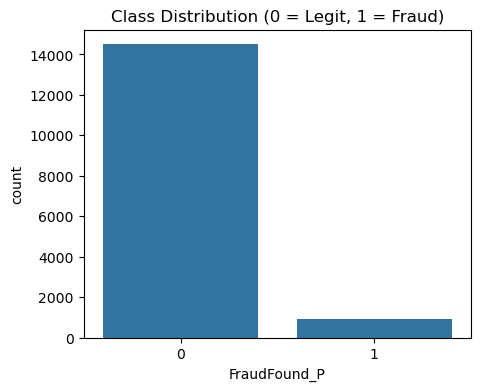

In [5]:
print(df['FraudFound_P'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='FraudFound_P', data=df)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()


In [6]:
cat_cols_eda = ['Make', 'AccidentArea', 'Sex', 'Fault', 'PolicyType', 'BasePolicy', 'AgeOfPolicyHolder']
for col in cat_cols_eda:
    fraud_rate = df.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False) * 100
    print(f"\n--- Fraud Rate % by {col} ---")
    print(fraud_rate.round(2))



--- Fraud Rate % by Make ---
Make
Mecedes      25.00
Accura       12.50
Saturn       10.34
Saab         10.19
Ford          7.33
Mercury       7.23
BMW           6.67
Honda         6.39
Toyota        5.96
Chevrolet     5.59
Pontiac       5.55
Mazda         5.23
Nisson        3.33
VW            2.83
Dodge         1.83
Lexus         0.00
Porche        0.00
Jaguar        0.00
Ferrari       0.00
Name: FraudFound_P, dtype: float64

--- Fraud Rate % by AccidentArea ---
AccidentArea
Rural    8.33
Urban    5.72
Name: FraudFound_P, dtype: float64

--- Fraud Rate % by Sex ---
Sex
Male      6.29
Female    4.34
Name: FraudFound_P, dtype: float64

--- Fraud Rate % by Fault ---
Fault
Policy Holder    7.89
Third Party      0.88
Name: FraudFound_P, dtype: float64

--- Fraud Rate % by PolicyType ---
PolicyType
Sport - Collision       13.79
Utility - All Perils    12.06
Sedan - All Perils      10.06
Utility - Collision     10.00
Sedan - Collision        6.88
Sedan - Liability        0.72
Sport - All Pe

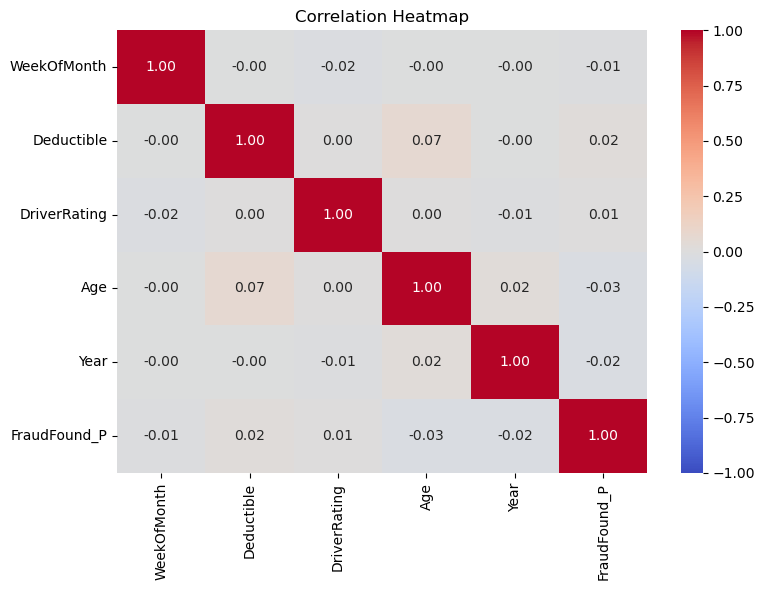

In [7]:
numeric_cols = ['WeekOfMonth', 'Deductible', 'DriverRating', 'Age', 'Year', 'FraudFound_P']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 4. Feature Engineering
Same core steps as the original notebook:
- Group rare `Make` values (< 50 occurrences) into `Other`
- Impute `Age == 0` using median age within `AgeOfPolicyHolder` bucket
- Ordinal-encode ordered categorical columns
- One-hot encode nominal columns
- Drop identifier column


In [8]:
make_counts = df["Make"].value_counts()
rare_makes = make_counts[make_counts < 50].index
df["Make"] = df["Make"].replace(rare_makes, "Other")

df["Age"] = df["Age"].replace(0, np.nan)
df["Age"] = df.groupby("AgeOfPolicyHolder")["Age"].transform(lambda x: x.fillna(x.median()))
df["Age"] = df["Age"].fillna(df["Age"].median())

ordinal_cols = [
    "Days_Policy_Accident", "Days_Policy_Claim", "AgeOfVehicle", "AgeOfPolicyHolder",
    "PastNumberOfClaims", "NumberOfSuppliments", "AddressChange_Claim", "NumberOfCars",
]
for col in ordinal_cols:
    df[col] = df[col].astype("category").cat.as_ordered()
    df[col] = df[col].cat.codes  # encode immediately, avoids leakage-prone split-time encoding

nominal_cols = [
    "Make", "AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType",
    "VehicleCategory", "VehiclePrice", "PoliceReportFiled", "WitnessPresent",
    "AgentType", "BasePolicy", "Month", "DayOfWeek", "MonthClaimed", "DayOfWeekClaimed",
]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

if "PolicyNumber" in df.columns:
    df.drop(columns=["PolicyNumber"], inplace=True)

print(df.shape)


(15419, 88)


## 5. Train / Test Split & Scaling

In [9]:
X = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train fraud rate:", y_train.mean().round(4), " Test fraud rate:", y_test.mean().round(4))


Train: (12335, 87)  Test: (3084, 87)
Train fraud rate: 0.0598  Test fraud rate: 0.06


### Imbalance-handled training sets
Build SMOTE-oversampled and undersampled versions of the *training* set only (never touch test set) so
we can compare imbalance-handling strategies fairly.


In [10]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print("Original :", y_train.value_counts().to_dict())
print("SMOTE    :", y_train_smote.value_counts().to_dict())
print("Undersamp:", y_train_rus.value_counts().to_dict())


Original : {0: 11597, 1: 738}
SMOTE    : {1: 11597, 0: 11597}
Undersamp: {0: 738, 1: 738}


## 6. Helper Functions
Reusable evaluation, threshold-optimization, and plotting utilities used for every model.

In [11]:
results = {}          # model_name -> dict of metrics (at 0.5 and at best threshold)
proba_store = {}       # model_name -> predicted probabilities on X_test
fitted_models = {}      # model_name -> fitted estimator

def best_threshold_by_fbeta(y_true, y_proba, beta=1.5):
    """Scan thresholds 0.01-0.99, return threshold maximizing F-beta
    (beta>1 weights recall higher, appropriate for fraud where missing fraud is costlier)."""
    thresholds = np.linspace(0.01, 0.99, 99)
    scores = [fbeta_score(y_true, (y_proba >= t).astype(int), beta=beta, zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], scores[best_idx]

def evaluate_model(name, model, X_te, y_te, y_proba):
    roc = roc_auc_score(y_te, y_proba)
    pr = average_precision_score(y_te, y_proba)

    y_pred_50 = (y_proba >= 0.5).astype(int)
    f1_50 = f1_score(y_te, y_pred_50, zero_division=0)

    best_t, best_f15 = best_threshold_by_fbeta(y_te, y_proba, beta=1.5)
    y_pred_best = (y_proba >= best_t).astype(int)

    report_best = classification_report(y_te, y_pred_best, output_dict=True, zero_division=0)

    results[name] = {
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "F1@0.5": f1_50,
        "Best_Threshold": best_t,
        "F1.5@BestThr": best_f15,
        "Precision@BestThr": report_best["1"]["precision"],
        "Recall@BestThr": report_best["1"]["recall"],
        "F1@BestThr": report_best["1"]["f1-score"],
    }
    proba_store[name] = y_proba
    fitted_models[name] = model

    print(f"=== {name} ===")
    print(f"ROC-AUC: {roc:.4f}  |  PR-AUC: {pr:.4f}  |  Best threshold: {best_t:.2f}")
    print(classification_report(y_te, y_pred_best, zero_division=0))
    print(confusion_matrix(y_te, y_pred_best))
    print()


## 7. Baseline — Logistic Regression

In [12]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
proba = lr.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression (balanced)", lr, X_test_scaled, y_test, proba)


=== Logistic Regression (balanced) ===
ROC-AUC: 0.8108  |  PR-AUC: 0.1645  |  Best threshold: 0.61
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      2899
           1       0.15      0.74      0.25       185

    accuracy                           0.73      3084
   macro avg       0.56      0.73      0.54      3084
weighted avg       0.93      0.73      0.80      3084

[[2129  770]
 [  49  136]]



In [13]:
# Logistic Regression trained on SMOTE-resampled data
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_smote, y_train_smote)
proba = lr_smote.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression (SMOTE)", lr_smote, X_test_scaled, y_test, proba)


=== Logistic Regression (SMOTE) ===
ROC-AUC: 0.8053  |  PR-AUC: 0.1590  |  Best threshold: 0.51
              precision    recall  f1-score   support

           0       0.98      0.67      0.79      2899
           1       0.14      0.84      0.24       185

    accuracy                           0.68      3084
   macro avg       0.56      0.75      0.52      3084
weighted avg       0.93      0.68      0.76      3084

[[1930  969]
 [  30  155]]



## 8. Tree-Based & Ensemble Models
Trained on unscaled features (tree models don't need scaling).

In [14]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
proba = dt.predict_proba(X_test)[:, 1]
evaluate_model("Decision Tree", dt, X_test, y_test, proba)


=== Decision Tree ===
ROC-AUC: 0.8138  |  PR-AUC: 0.1973  |  Best threshold: 0.70
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      2899
           1       0.18      0.61      0.27       185

    accuracy                           0.81      3084
   macro avg       0.57      0.71      0.58      3084
weighted avg       0.92      0.81      0.85      3084

[[2373  526]
 [  72  113]]



In [15]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", rf, X_test, y_test, proba)


=== Random Forest ===
ROC-AUC: 0.8369  |  PR-AUC: 0.2417  |  Best threshold: 0.13
              precision    recall  f1-score   support

           0       0.97      0.88      0.92      2899
           1       0.21      0.52      0.30       185

    accuracy                           0.85      3084
   macro avg       0.59      0.70      0.61      3084
weighted avg       0.92      0.85      0.88      3084

[[2539  360]
 [  89   96]]



In [16]:
et = ExtraTreesClassifier(class_weight='balanced', n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
et.fit(X_train, y_train)
proba = et.predict_proba(X_test)[:, 1]
evaluate_model("Extra Trees", et, X_test, y_test, proba)


=== Extra Trees ===
ROC-AUC: 0.8321  |  PR-AUC: 0.2186  |  Best threshold: 0.09
              precision    recall  f1-score   support

           0       0.98      0.75      0.85      2899
           1       0.17      0.77      0.27       185

    accuracy                           0.75      3084
   macro avg       0.57      0.76      0.56      3084
weighted avg       0.93      0.75      0.82      3084

[[2186  713]
 [  43  142]]



In [17]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
proba = gb.predict_proba(X_test)[:, 1]
evaluate_model("Gradient Boosting", gb, X_test, y_test, proba)


=== Gradient Boosting ===
ROC-AUC: 0.8363  |  PR-AUC: 0.2260  |  Best threshold: 0.12
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2899
           1       0.19      0.59      0.29       185

    accuracy                           0.83      3084
   macro avg       0.58      0.72      0.60      3084
weighted avg       0.92      0.83      0.87      3084

[[2444  455]
 [  75  110]]



In [18]:
ada = AdaBoostClassifier(n_estimators=300, learning_rate=0.1, random_state=RANDOM_STATE)
ada.fit(X_train, y_train)
proba = ada.predict_proba(X_test)[:, 1]
evaluate_model("AdaBoost", ada, X_test, y_test, proba)


=== AdaBoost ===
ROC-AUC: 0.8073  |  PR-AUC: 0.1483  |  Best threshold: 0.28
              precision    recall  f1-score   support

           0       1.00      0.57      0.73      2899
           1       0.13      0.97      0.22       185

    accuracy                           0.60      3084
   macro avg       0.56      0.77      0.47      3084
weighted avg       0.94      0.60      0.70      3084

[[1657 1242]
 [   6  179]]



In [19]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=300, max_depth=5,
    learning_rate=0.1, eval_metric='logloss', random_state=RANDOM_STATE
)
xgb.fit(X_train, y_train)
proba = xgb.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", xgb, X_test, y_test, proba)


=== XGBoost ===
ROC-AUC: 0.8360  |  PR-AUC: 0.2383  |  Best threshold: 0.41
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      2899
           1       0.19      0.65      0.29       185

    accuracy                           0.81      3084
   macro avg       0.58      0.74      0.59      3084
weighted avg       0.93      0.81      0.86      3084

[[2382  517]
 [  65  120]]



In [20]:
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
)
lgbm.fit(X_train, y_train)
proba = lgbm.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM", lgbm, X_test, y_test, proba)


=== LightGBM ===
ROC-AUC: 0.8414  |  PR-AUC: 0.2304  |  Best threshold: 0.32
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      2899
           1       0.19      0.74      0.31       185

    accuracy                           0.80      3084
   macro avg       0.59      0.77      0.60      3084
weighted avg       0.93      0.80      0.85      3084

[[2331  568]
 [  48  137]]



In [21]:
cb = CatBoostClassifier(
    iterations=300, depth=5, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0
)
cb.fit(X_train, y_train)
proba = cb.predict_proba(X_test)[:, 1]
evaluate_model("CatBoost", cb, X_test, y_test, proba)


=== CatBoost ===
ROC-AUC: 0.8599  |  PR-AUC: 0.2450  |  Best threshold: 0.39
              precision    recall  f1-score   support

           0       0.99      0.77      0.86      2899
           1       0.19      0.84      0.31       185

    accuracy                           0.77      3084
   macro avg       0.59      0.81      0.59      3084
weighted avg       0.94      0.77      0.83      3084

[[2228  671]
 [  29  156]]



## 9. Distance-Based & Probabilistic Models
(Scaled features required.)

In [22]:
knn = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn.fit(X_train_smote, y_train_smote)   # KNN needs balanced data since it has no class_weight
proba = knn.predict_proba(X_test_scaled)[:, 1]
evaluate_model("KNN (SMOTE)", knn, X_test_scaled, y_test, proba)


=== KNN (SMOTE) ===
ROC-AUC: 0.7077  |  PR-AUC: 0.1150  |  Best threshold: 0.60
              precision    recall  f1-score   support

           0       0.97      0.65      0.78      2899
           1       0.11      0.67      0.19       185

    accuracy                           0.66      3084
   macro avg       0.54      0.66      0.49      3084
weighted avg       0.92      0.66      0.75      3084

[[1898 1001]
 [  61  124]]



In [23]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
proba = nb.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Naive Bayes", nb, X_test_scaled, y_test, proba)


=== Naive Bayes ===
ROC-AUC: 0.7458  |  PR-AUC: 0.1235  |  Best threshold: 0.99
              precision    recall  f1-score   support

           0       0.98      0.18      0.31      2899
           1       0.07      0.95      0.13       185

    accuracy                           0.23      3084
   macro avg       0.53      0.57      0.22      3084
weighted avg       0.93      0.23      0.30      3084

[[ 532 2367]
 [   9  176]]



In [24]:
# SVM is expensive on the full training set -> train on the smaller undersampled set
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_rus, y_train_rus)
proba = svm.predict_proba(X_test_scaled)[:, 1]
evaluate_model("SVM (RBF, undersampled)", svm, X_test_scaled, y_test, proba)


=== SVM (RBF, undersampled) ===
ROC-AUC: 0.7906  |  PR-AUC: 0.1458  |  Best threshold: 0.48
              precision    recall  f1-score   support

           0       0.99      0.62      0.76      2899
           1       0.13      0.89      0.23       185

    accuracy                           0.64      3084
   macro avg       0.56      0.76      0.50      3084
weighted avg       0.94      0.64      0.73      3084

[[1802 1097]
 [  20  165]]



## 10. Hyperparameter Tuning
Tune the strongest tree-based candidates (Random Forest, XGBoost, LightGBM) with `RandomizedSearchCV`,
optimizing average precision (PR-AUC) since the classes are heavily imbalanced.


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 6, 10, 14, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=25, scoring='average_precision', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)

rf_tuned = rf_search.best_estimator_
proba = rf_tuned.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest (Tuned)", rf_tuned, X_test, y_test, proba)


Best RF params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 14}
=== Random Forest (Tuned) ===
ROC-AUC: 0.8390  |  PR-AUC: 0.2360  |  Best threshold: 0.41
              precision    recall  f1-score   support

           0       0.98      0.81      0.88      2899
           1       0.19      0.71      0.30       185

    accuracy                           0.80      3084
   macro avg       0.58      0.76      0.59      3084
weighted avg       0.93      0.80      0.85      3084

[[2334  565]
 [  54  131]]



In [26]:
xgb_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE),
    xgb_param_dist, n_iter=25, scoring='average_precision', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)

xgb_tuned = xgb_search.best_estimator_
proba = xgb_tuned.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost (Tuned)", xgb_tuned, X_test, y_test, proba)


Best XGB params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
=== XGBoost (Tuned) ===
ROC-AUC: 0.8456  |  PR-AUC: 0.2312  |  Best threshold: 0.38
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2899
           1       0.18      0.81      0.30       185

    accuracy                           0.77      3084
   macro avg       0.58      0.79      0.58      3084
weighted avg       0.94      0.77      0.83      3084

[[2233  666]
 [  36  149]]



In [27]:
lgbm_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 63, 127],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
    lgbm_param_dist, n_iter=25, scoring='average_precision', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train, y_train)
print("Best LGBM params:", lgbm_search.best_params_)

lgbm_tuned = lgbm_search.best_estimator_
proba = lgbm_tuned.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM (Tuned)", lgbm_tuned, X_test, y_test, proba)


Best LGBM params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
=== LightGBM (Tuned) ===
ROC-AUC: 0.8366  |  PR-AUC: 0.2374  |  Best threshold: 0.43
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2899
           1       0.17      0.74      0.28       185

    accuracy                           0.77      3084
   macro avg       0.57      0.75      0.57      3084
weighted avg       0.93      0.77      0.83      3084

[[2229  670]
 [  48  137]]



## 11. Ensembles
Combine the tuned boosters + Random Forest via soft Voting and via Stacking (meta-learner = Logistic Regression).


In [28]:
voting = VotingClassifier(
    estimators=[
        ("rf", rf_tuned),
        ("xgb", xgb_tuned),
        ("lgbm", lgbm_tuned),
    ],
    voting="soft", n_jobs=-1
)
voting.fit(X_train, y_train)
proba = voting.predict_proba(X_test)[:, 1]
evaluate_model("Voting Ensemble (RF+XGB+LGBM)", voting, X_test, y_test, proba)


=== Voting Ensemble (RF+XGB+LGBM) ===
ROC-AUC: 0.8467  |  PR-AUC: 0.2392  |  Best threshold: 0.40
              precision    recall  f1-score   support

           0       0.98      0.77      0.87      2899
           1       0.18      0.78      0.29       185

    accuracy                           0.77      3084
   macro avg       0.58      0.78      0.58      3084
weighted avg       0.93      0.77      0.83      3084

[[2243  656]
 [  40  145]]



In [29]:
stacking = StackingClassifier(
    estimators=[
        ("rf", rf_tuned),
        ("xgb", xgb_tuned),
        ("lgbm", lgbm_tuned),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    stack_method="predict_proba", cv=5, n_jobs=-1
)
stacking.fit(X_train, y_train)
proba = stacking.predict_proba(X_test)[:, 1]
evaluate_model("Stacking Ensemble (RF+XGB+LGBM -> LR)", stacking, X_test, y_test, proba)


=== Stacking Ensemble (RF+XGB+LGBM -> LR) ===
ROC-AUC: 0.8466  |  PR-AUC: 0.2395  |  Best threshold: 0.08
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2899
           1       0.18      0.79      0.29       185

    accuracy                           0.77      3084
   macro avg       0.58      0.78      0.58      3084
weighted avg       0.94      0.77      0.83      3084

[[2231  668]
 [  38  147]]



## 12. Cross-Validation Robustness Check
5-fold stratified CV (PR-AUC) for the top candidates, to confirm the held-out test result isn't a lucky split.


In [30]:
cv_models = {
    "Random Forest (Tuned)": rf_tuned,
    "XGBoost (Tuned)": xgb_tuned,
    "LightGBM (Tuned)": lgbm_tuned,
    "CatBoost": cb,
    "Voting Ensemble (RF+XGB+LGBM)": voting,
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name}: PR-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")


Random Forest (Tuned): PR-AUC = 0.2567 +/- 0.0246
XGBoost (Tuned): PR-AUC = 0.2493 +/- 0.0279
LightGBM (Tuned): PR-AUC = 0.2615 +/- 0.0392
CatBoost: PR-AUC = 0.2341 +/- 0.0361
Voting Ensemble (RF+XGB+LGBM): PR-AUC = 0.2675 +/- 0.0300


## 13. Final Model Comparison

In [31]:
comparison_df = pd.DataFrame(results).T.sort_values("PR_AUC", ascending=False)
comparison_df = comparison_df.round(4)
comparison_df


,ROC_AUC,PR_AUC,F1@0.5,Best_Threshold,F1.5@BestThr,Precision@BestThr,Recall@BestThr,F1@BestThr
CatBoost,0.8599,0.2450,0.3030,0.39,0.4078,0.1886,0.8432,0.3083
Random Forest,0.8369,0.2417,0.0108,0.13,0.3577,0.2105,0.5189,0.2995
Stacking Ensemble (RF+XGB+LGBM -> LR),0.8466,0.2395,0.0526,0.08,0.3880,0.1804,0.7946,0.2940
Voting Ensemble (RF+XGB+LGBM),0.8467,0.2392,0.2913,0.40,0.3871,0.1810,0.7838,0.2941
XGBoost,0.8360,0.2383,0.2883,0.41,0.3703,0.1884,0.6486,0.2920
LightGBM (Tuned),0.8366,0.2374,0.2850,0.43,0.3640,0.1698,0.7405,0.2762
Random Forest (Tuned),0.8390,0.2360,0.2837,0.41,0.3828,0.1882,0.7081,0.2974
XGBoost (Tuned),0.8456,0.2312,0.2979,0.38,0.3933,0.1828,0.8054,0.2980
LightGBM,0.8414,0.2304,0.2857,0.32,0.3971,0.1943,0.7405,0.3079
Gradient Boosting,0.8363,0.2260,0.0521,0.12,0.3643,0.1947,0.5946,0.2933


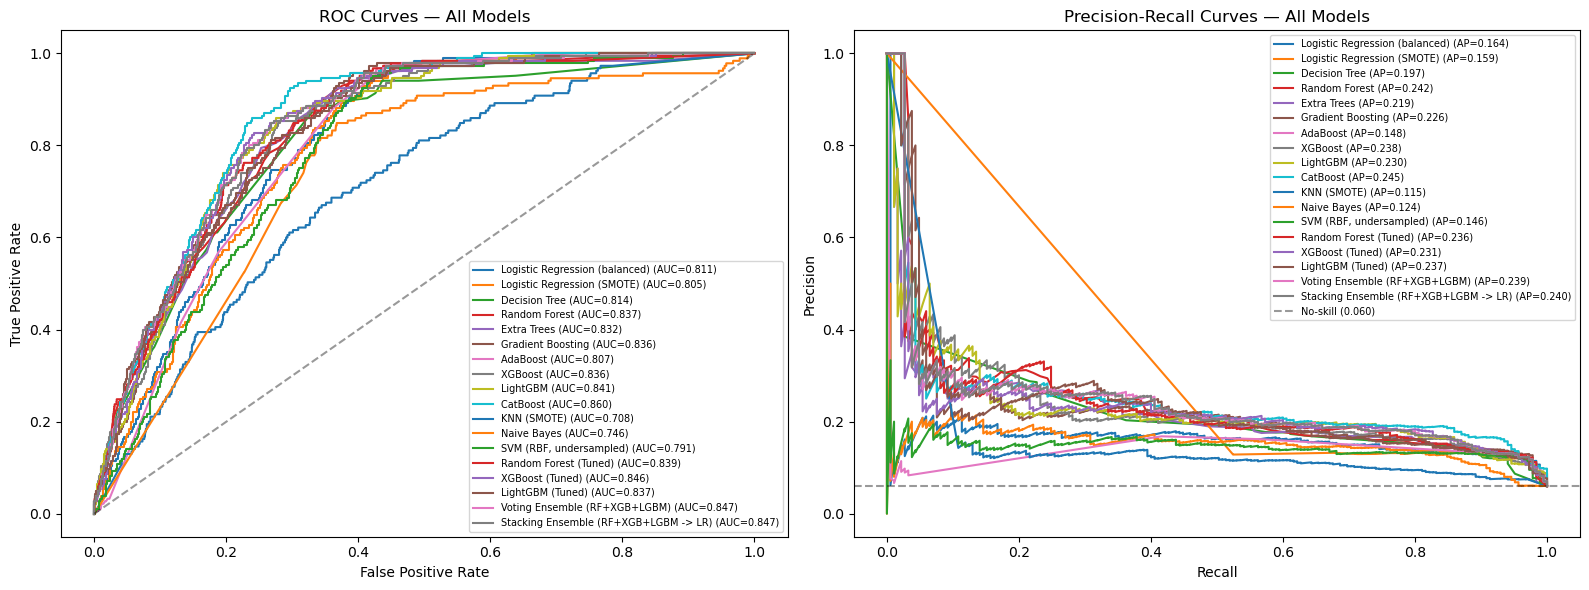

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
for name, proba in proba_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC_AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models")
axes[0].legend(fontsize=7, loc="lower right")

# PR curves
for name, proba in proba_store.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['PR_AUC']:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"No-skill ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — All Models")
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

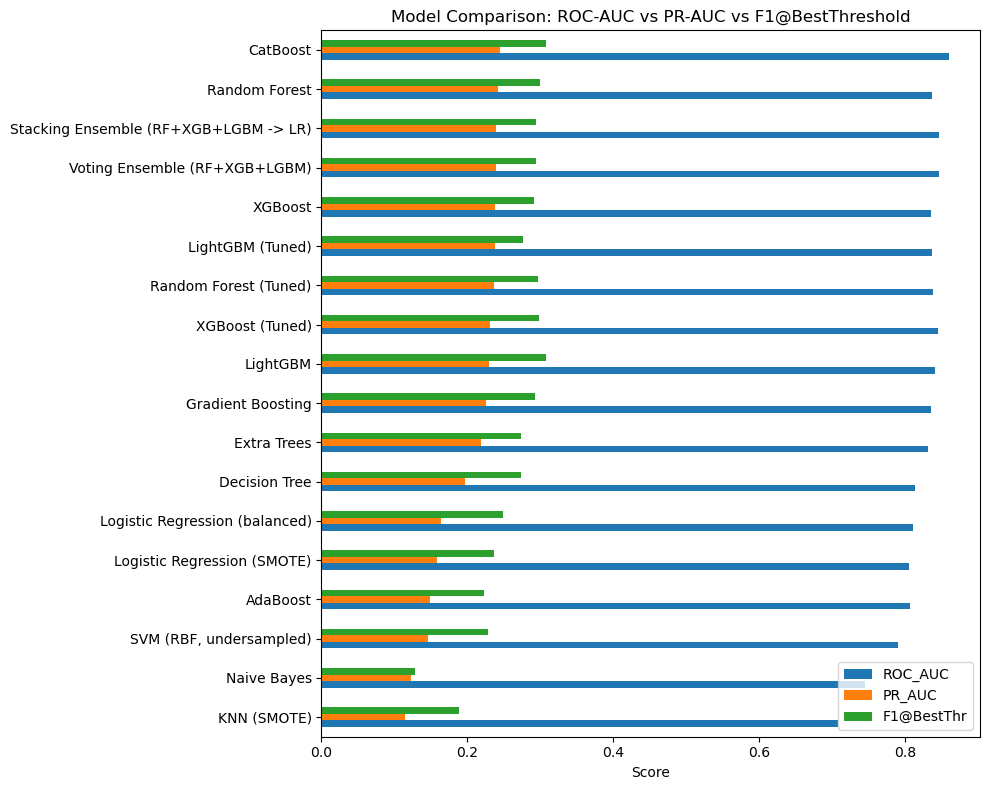

In [33]:
plt.figure(figsize=(10, 6))
plot_df = comparison_df[["ROC_AUC", "PR_AUC", "F1@BestThr"]].sort_values("PR_AUC")
plot_df.plot(kind="barh", figsize=(10, 8))
plt.title("Model Comparison: ROC-AUC vs PR-AUC vs F1@BestThreshold")
plt.xlabel("Score")
plt.tight_layout()
plt.show()


## 14. Best Model Deep-Dive
Pick the model with the highest PR-AUC (most informative metric for this ~6% fraud base rate) for
feature importance and SHAP explainability.


Best model: CatBoost  |  Best threshold: 0.39


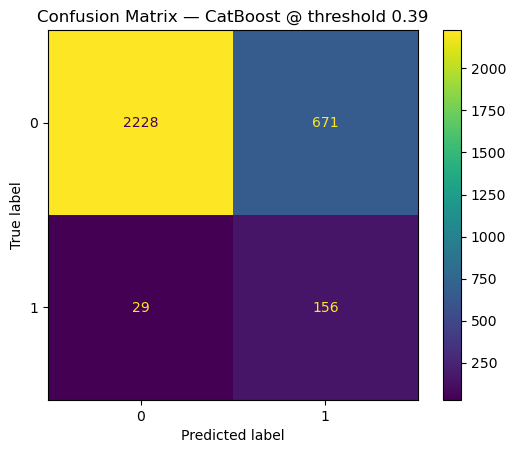

              precision    recall  f1-score   support

           0       0.99      0.77      0.86      2899
           1       0.19      0.84      0.31       185

    accuracy                           0.77      3084
   macro avg       0.59      0.81      0.59      3084
weighted avg       0.94      0.77      0.83      3084



In [34]:
best_name = comparison_df.index[0]
best_model = fitted_models[best_name]
best_thr = results[best_name]["Best_Threshold"]
print(f"Best model: {best_name}  |  Best threshold: {best_thr:.2f}")

best_proba = proba_store[best_name]
best_pred = (best_proba >= best_thr).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f"Confusion Matrix — {best_name} @ threshold {best_thr:.2f}")
plt.show()

print(classification_report(y_test, best_pred, zero_division=0))


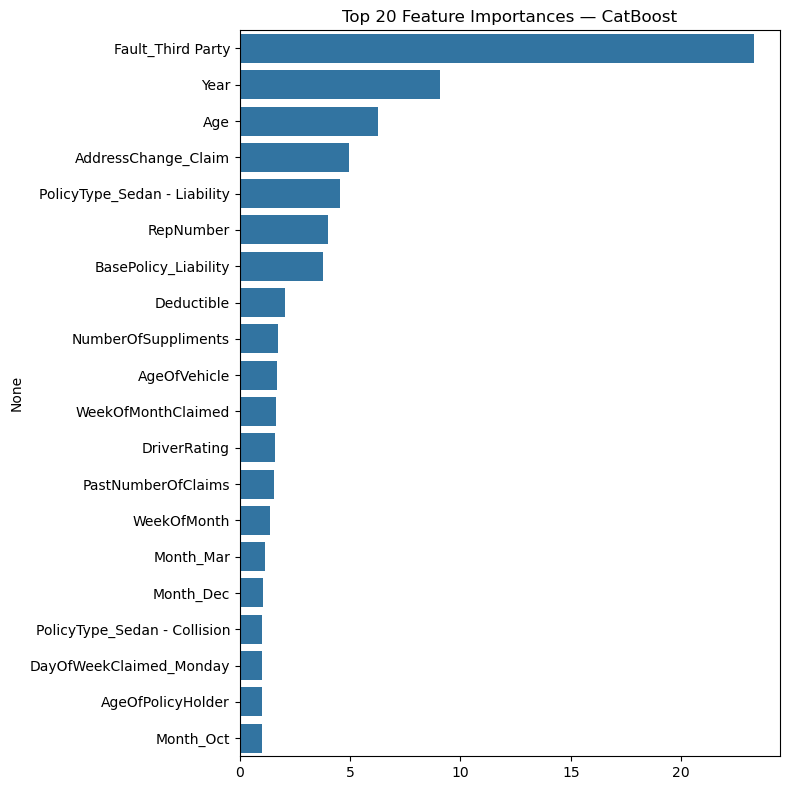

In [35]:
# Feature importance (works for tree-based models; skip gracefully otherwise)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8, 8))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Top 20 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} has no native feature_importances_ attribute.")


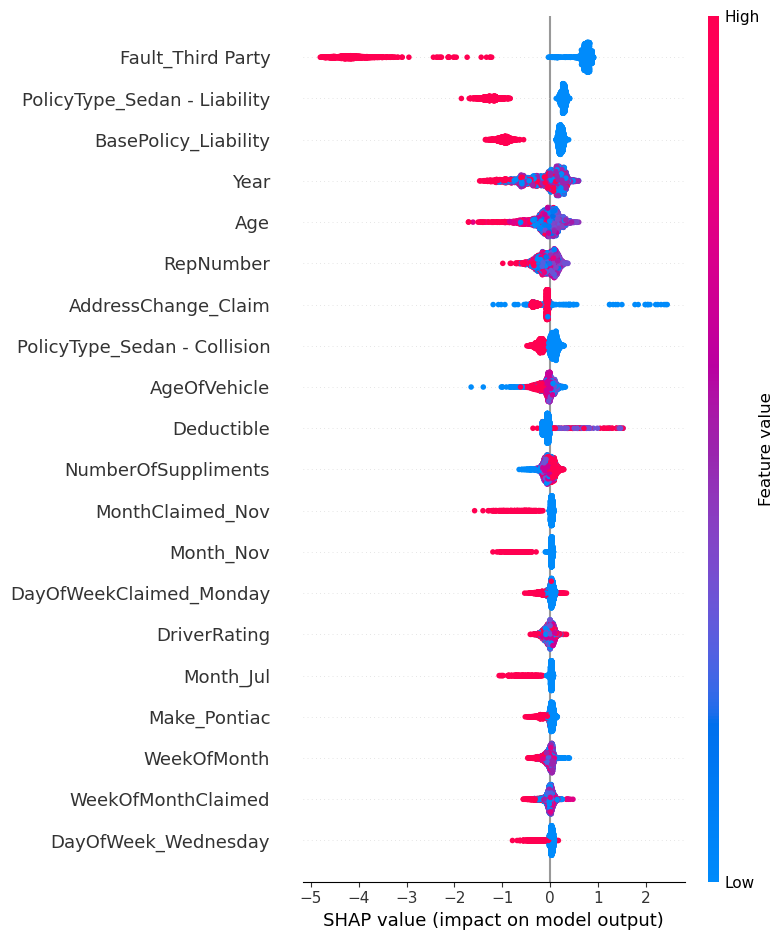

In [36]:
# SHAP explainability for the best model (tree-based models supported by TreeExplainer)
import shap

try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    # Some models return a list per class; take the positive-class values
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_test, show=True)
except Exception as e:
    print("SHAP TreeExplainer not applicable to this model:", e)


## 15. Save Best Model

In [37]:
joblib.dump(best_model, "best_fraud_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
print(f"Saved '{best_name}' to best_fraud_model.pkl")


Saved 'CatBoost' to best_fraud_model.pkl
